In [28]:
!pip install pdfplumber
!pip install nltk


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# ==========================================
# CONVERT GATE TF PDFs INTO TEXT
# ==========================================

import pdfplumber
import os
from pathlib import Path


# Folder containing PDFs
PDF_FOLDER = r"D:\GATE_topic_predictor\dataset"

# Dictionary to store all extracted text
all_papers = {}

# Read all PDF files
for file in os.listdir(PDF_FOLDER):

    # Check only PDF files
    if file.endswith(".pdf"):

        # Full file path
        pdf_path = os.path.join(PDF_FOLDER, file)

        print(f"\nReading: {file}")

        # Store text for current PDF
        full_text = ""

        try:

            # Open PDF
            with pdfplumber.open(pdf_path) as pdf:

                # Read all pages
                for page in pdf.pages:

                    text = page.extract_text()

                    # Add text if page not empty
                    if text:
                        full_text += text + "\n"

            # Store extracted text
            all_papers[file] = full_text

            print(f"Successfully extracted: {file}")

        except Exception as e:

            print(f"Error reading {file}")
            print(e)

# ==========================================
# PRINT SAMPLE OUTPUT
# ==========================================

print("\n===================================")
print("SAMPLE OUTPUT")
print("===================================")

for file_name, content in all_papers.items():

    print(f"\nFILE: {file_name}")

    print(content[:1500])

    break


Reading: TFQ_2011.pdf
Successfully extracted: TFQ_2011.pdf

Reading: TFQ_2012.pdf
Successfully extracted: TFQ_2012.pdf

Reading: TFQ_2013.pdf
Successfully extracted: TFQ_2013.pdf

Reading: TFQ_2014.pdf
Successfully extracted: TFQ_2014.pdf

Reading: TFQ_2015.pdf
Successfully extracted: TFQ_2015.pdf

Reading: TFQ_2016.pdf
Successfully extracted: TFQ_2016.pdf

Reading: TFQ_2017.pdf
Successfully extracted: TFQ_2017.pdf

Reading: TFQ_2018.pdf
Successfully extracted: TFQ_2018.pdf

Reading: TFQ_2019.pdf
Successfully extracted: TFQ_2019.pdf

Reading: TFQ_2020.pdf
Successfully extracted: TFQ_2020.pdf

Reading: TFQ_2021.pdf
Successfully extracted: TFQ_2021.pdf

Reading: TFQ_2022.pdf
Successfully extracted: TFQ_2022.pdf

Reading: TFQ_2023.pdf
Successfully extracted: TFQ_2023.pdf

Reading: TFQ_2024.pdf
Successfully extracted: TFQ_2024.pdf

Reading: TFQ_2025.pdf
Successfully extracted: TFQ_2025.pdf

Reading: TFQ_2026.pdf
Successfully extracted: TFQ_2026.pdf

SAMPLE OUTPUT

FILE: TFQ_2011.pdf
2011 

In [30]:
# ==========================================
# CREATE TOPIC FREQUENCY CSV
# ==========================================

import os
import re
import pandas as pd
import nltk

from collections import defaultdict
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# ==========================================
# DOWNLOAD NLTK DATA
# ==========================================
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
# ==========================================
# STOPWORDS
# ==========================================

stop_words = set(stopwords.words('english'))

# ==========================================
# PDF FOLDER
# ==========================================

PDF_FOLDER = r"D:\GATE_topic_predictor\dataset"

# ==========================================
# YOUR TOPIC MAPPING
# ==========================================

topics = {

#fiber science
"Fiber Science": [
"cotton","wool","silk","jute","flax","hemp","ramie","kenaf",
"animal fibre","vegetable fibre","natural fibre",
"cellulose","hemicellulose","lignin","pectin","wax",
"fibroin","sericin","keratin",
"cuticle","cortex","medulla","lumen",
"primary wall","secondary wall",
"fibre morphology","cross section",
"micronaire","maturity coefficient",
"convolution","crimp","fineness",
"tenacity","elongation","modulus",
"specific gravity","density",
"moisture regain","moisture content",
"hygroscopicity","absorbency",
"fibre identification","burn test",
"solubility test","longitudinal view",
"transverse section","fibre damage",
"immature fibre","dead fibre",
"neps","trash","seed coat fragment"
],

#polymer science
"Polymer Science":[
"polymer","monomer","oligomer",
"copolymer","homopolymer",
"block copolymer","random copolymer",
"PET",
"graft copolymer",
"addition polymerization",
"condensation polymerization",
"chain growth polymerization",
"step growth polymerization",
"free radical polymerization",
"anion polymerization",
"cation polymerization",
"suspension polymerization",
"solution polymerization",
"bulk polymerization",
"emulsion polymerization",
"molecular weight",
"number average molecular weight",
"caprolactam","styrene","acrylonitrile",
"POY","FOY","tow","filament","UHMWPE","HMWPE",
"melt","adipic acid","terephthalic acid","nylon 6","nylon 66","monomer",
"weight average molecular weight",
"polydispersity index",
"glass transition temperature",
"melting temperature",
"crystallinity","amorphous",
"orientation","chain folding",
"crosslinking","branching",
"creep","stress relaxation",
"viscoelasticity",
"isotactic","syndiotactic","atactic",
"polyethylene","polypropylene",
"polystyrene","polyamide",
"polyester","polyacrylonitrile"
],

#man made fibres
"Man Made Fibres": [
"viscose","rayon","modal","lyocell",
"polynosic","acetate","triacetate",
"polyester","pet","nylon","acrylic",
"polypropylene","spandex",
"elastane","aramid","kevlar",
"nomex","carbon fibre","glass fibre",
"wet spinning","dry spinning",
"melt spinning","gel spinning",
"solution spinning",
"spinneret","extrusion",
"drawing","heat setting",
"texturizing","false twist",
"tow","filament","staple",
"dope","coagulation bath",
"regeneration","viscose process",
"xanthation","ripening"
],

#spinning process
"Spinning": [
"blowroom","opening","cleaning",
"mixing","blending","lap",
"carding","card","flat top",
"cylinder","doffer","licker in",
"sliver","drawframe","autoleveller",
"doubling","drafting system",
"comber","combing","top comb",
"nipper","detaching roller",
"noil","speed frame",
"fly frame","simplex",
"roving","ring frame",
"ring spinning",
"traveller","spindle",
"balloon","cop",
],

#evenness and quality control
"Evenness & Quality Control": [
"evenness","coefficient of variation",
"imperfection","thin places",
"compact spinning",
"draft","break draft",
"total draft","roller setting",
"twist","twist multiplier",
"clearer","package density"
"yarn count","tex",
"denier","english count",
"hairiness","imperfection",
"thin places","thick places",
"neps","winding",
"autoconer","splicer","Irregulariy","yarn fault","yarn defect"
],

#modern spinning process
"modern spinning": [
    "rotor spinning",
"open end spinning",
"air jet spinning",
"friction spinning",
"compact spinning",
"rotor diameter","rotor speed",
"rotor speed","rotor"
"twillow","bobtex","hollow spinning",
"vortex spinning","siro spinning","MVS","electrostatic spinning","wrap spinning",
"core spun yarn","slub yarn","boucle yarn","chenille yarn","fancy yarn","textured yarn",
"core spinning","dref-2","Dref-3","dref-300","dref"
],
#weaving process
"Weaving": [
"warp","weft","loom",
"shedding","picking",
"beating up","reed",
"heald","heddle",
"shuttle","pirn",
"rapier","projectile",
"air jet loom","water jet loom",
"warp stop motion",
"weft stop motion",
"let off motion",
"take up motion",
"warping","beam warping",
"sectional warping",
"padding mangle",
"sizing","size box",
"dobby","jacquard",
"plain weave","twill weave",
"satin weave","basket weave",
"fabric cover factor",
"ends per inch",
"picks per inch",
"crimp","loom efficiency"
],

#knitting process
"Knitting": [
"knitting","weft knitting",
"warp knitting",
"single jersey","rib",
"interlock","purl",
"tricot","raschel",
"needle","latch needle",
"compound needle",
"bearded needle",
"sinker","cam",
"loop","loop length",
"loop shape factor",
"wale","course",
"knit stitch","tuck stitch",
"miss stitch",
"circular knitting machine",
"flat knitting machine",
"gauge","stitch density"
],

#nonwoven process
"Nonwovens": [
"nonwoven","web formation",
"spunbond","meltblown",
"needle punching",
"hydroentanglement",
"spunlace","thermal bonding",
"chemical bonding",
"mechanical bonding",
"Perpendicular laid","random laid",
"airlaid","wetlaid",
"drylaid","calendar bonding",
"needle loom","barb",
"stripper plate",
"geotextile nonwoven"
],

#chemical processing
"Chemical Processing": [
"desizing","scouring",
"bleaching","mercerization",
"singeing","carbonizing",
"dyeing","printing",
"finishing",
"reactive dye","direct dye",
"vat dye","sulphur dye",
"acid dye","basic dye",
"disperse dye","azo dye",
"pigment printing",
"discharge printing",
"resist printing",
"screen printing",
"roller printing",
"padding","batching",
"exhaustion","fixation",
"electrolyte","salt",
"soda ash","levelling agent",
"wash fastness",
"light fastness",
"rubbing fastness",
"perspiration fastness",
"anti crease finish",
"flame retardant finish",
"water repellent finish",
"enzyme wash",
"bio polishing",
"softener"
],

#textile testing
"Textile Testing": [
    "tensile strength","elongation",
    "tear strength","bursting strength",
    "abrasion resistance",
    "pilling","crease recovery",
    "fabric stiffness","bending length",
    "drape","air permeability",
    "wicking","moisture management",
    "evenness tester","uster",
    "fibrogram","hvi",
    "afis","capacitance tester",
    "microscopy",
    "dsc","dma","tga",
    "ftir","ir spectroscopy",
    "xrd","x ray diffraction",
    "sem","tem",
    "colour fastness",
    "fabric testing",
    "yarn testing",
    "fibre testing"
],

#garment manufacturing
"Garment Manufacturing": [
    "garment","apparel",
    "pattern making","grading",
    "marker planning","marker efficiency",
    "spreading","cutting",
    "stitch","seam","spi",
    "smv","sam",
    "line balancing",
    "work study","method study",
    "seam","stitch","spi",
    "time study",
    "production planning",
    "bundle system",
    "modular production",
    "garment costing",
    "quality inspection",
    "needle damage",
    "fusing","pressing"
],

#technical textiles
"Technical Textiles": [
    "technical textile",
    "composite",
    "filter cloth",
    "geotextile","agrotextile",
    "meditech","mobiltech",
    "sportech","packtech",
    "hometech","clothtech",
    "buildtech","indutech",
    "protech","ecotech",
    "composite","reinforcement",
    "retardant","flame retardant",
    "antimicrobial","waterproof",
    "water repellent","stain resistant",
    "ballistic protection",
    "bulletproof","fire resistant",
    "filter fabric",
    "medical implant",
    "smart textile",
    "conductive textile",
    "protective clothing"
],

#statistics and quality control
"Statistics & Quality Control": [
    "mean","median","mode",
    "variance","standard deviation",
    "coefficient of variation",
    "regression","correlation",
    "probability","bayes theorem",
    "binomial distribution",
    "poisson distribution",
    "normal distribution",
    "sampling","hypothesis testing",
    "f test","t test","chi square",
    "anova","control chart",
    "quality control",
    "acceptance sampling",
    "six sigma",
    "process capability",
    "design of experiments"
],

#engineering mathematics
"Engineering Mathematics": [
    "calculus","integration","differentiation",
    "ordinary differential equation",
    "partial differential equation",
    "laplace transform",
    "fourier series",
    "matrix","determinant",
    "eigenvalue","eigenvector",
    "vector calculus",
    "linear algebra",
    "numerical methods",
    "simpson rule",
    "trapezoidal rule",
    "optimization",
    "probability theory",
    "statistics",
    "complex variable",
    "series expansion",
    "taylor series",
    "linear programming"
],

#general aptitude
"General Aptitude": [
    "analogy","series","coding decoding",
    "blood relation","direction sense",
    "seating arrangement",
    "syllogism","logical reasoning",
    "critical reasoning",
    "data interpretation",
    "pie chart","bar chart",
    "percentage","profit loss",
    "ratio","proportion",
    "time and work",
    "permutation","combination",
    "probability",
    "grammar","vocabulary",
    "sentence correction",
    "reading comprehension",
    "para jumbles",
    "calendar","clock",
    "cube folding","paper folding"
]

}
# ==========================================
# CLEAN TEXT FUNCTION
# ==========================================

def clean_text(text):

    # Lowercase
    text = text.lower()

    # Remove numbers
    text = re.sub(r'\d+', ' ', text)

    # Remove punctuation
    text = re.sub(r'[^\w\s]', ' ', text)

    # Tokenize
    words = word_tokenize(text)

    # Remove stopwords
    filtered_words = []

    for word in words:

        if word not in stop_words:

            if len(word) > 2:

                filtered_words.append(word)

    return " ".join(filtered_words)

# ==========================================
# STORE RESULTS
# ==========================================

results = []

# ==========================================
# READ ALL PDF FILES
# ==========================================

for file in os.listdir(PDF_FOLDER):

    if file.endswith(".pdf"):

        pdf_path = os.path.join(PDF_FOLDER, file)

        print(f"\nProcessing: {file}")

        full_text = ""

        try:

            # ----------------------------------
            # EXTRACT TEXT
            # ----------------------------------

            with pdfplumber.open(pdf_path) as pdf:

                for page in pdf.pages:

                    text = page.extract_text()

                    if text:

                        full_text += text + "\n"

            # ----------------------------------
            # CLEAN TEXT
            # ----------------------------------

            cleaned_text = clean_text(full_text)

            # ----------------------------------
            # TOPIC COUNTING
            # ----------------------------------

            topic_count = defaultdict(int)

            for topic, keywords in topics.items():

                for keyword in keywords:

                    count = cleaned_text.count(keyword)

                    topic_count[topic] += count

            # ----------------------------------
            # EXTRACT YEAR
            # ----------------------------------

            year = file.replace("TFQ_", "")
            year = year.replace(".pdf", "")

            # ----------------------------------
            # SAVE RESULTS
            # ----------------------------------

            for topic, count in topic_count.items():

                results.append({

                    "Year": year,
                    "Topic": topic,
                    "Frequency": count

                })

            print(f"Completed: {file}")

        except Exception as e:

            print(f"Error processing {file}")
            print(e)

# ==========================================
# CREATE DATAFRAME
# ==========================================

df = pd.DataFrame(results)

# ==========================================
# DISPLAY SAMPLE
# ==========================================

print("\n===================================")
print("TOPIC FREQUENCY DATA")
print("===================================")

print(df.head(20))

# ==========================================
# SAVE CSV FILE
# ==========================================

output_path = r"D:\TF_Gate_Topic_predictor\data\topic_frequency.csv"

df.to_csv(output_path, index=False)

# ==========================================
# FINISHED
# ==========================================

print("\n===================================")
print("CSV FILE CREATED SUCCESSFULLY!")
print("===================================")

print(f"\nSaved at:\n{output_path}")


Processing: TFQ_2011.pdf


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\jayap\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\jayap\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jayap\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Completed: TFQ_2011.pdf

Processing: TFQ_2012.pdf
Completed: TFQ_2012.pdf

Processing: TFQ_2013.pdf
Completed: TFQ_2013.pdf

Processing: TFQ_2014.pdf
Completed: TFQ_2014.pdf

Processing: TFQ_2015.pdf
Completed: TFQ_2015.pdf

Processing: TFQ_2016.pdf
Completed: TFQ_2016.pdf

Processing: TFQ_2017.pdf
Completed: TFQ_2017.pdf

Processing: TFQ_2018.pdf
Completed: TFQ_2018.pdf

Processing: TFQ_2019.pdf
Completed: TFQ_2019.pdf

Processing: TFQ_2020.pdf
Completed: TFQ_2020.pdf

Processing: TFQ_2021.pdf
Completed: TFQ_2021.pdf

Processing: TFQ_2022.pdf
Completed: TFQ_2022.pdf

Processing: TFQ_2023.pdf
Completed: TFQ_2023.pdf

Processing: TFQ_2024.pdf
Completed: TFQ_2024.pdf

Processing: TFQ_2025.pdf
Completed: TFQ_2025.pdf

Processing: TFQ_2026.pdf
Completed: TFQ_2026.pdf

TOPIC FREQUENCY DATA
    Year                         Topic  Frequency
0   2011                 Fiber Science         21
1   2011               Polymer Science         15
2   2011               Man Made Fibres         16
3   

In [5]:
# ==========================================
# GATE TF TREND ANALYSIS
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


In [8]:
# ==========================================
# LOAD CSV FILE
# ==========================================

from pathlib import Path

# Notebook-safe base directory: prefer current folder, fallback to parent
BASE_DIR = Path().resolve()

if (BASE_DIR / "data").exists():
    DATA_DIR = BASE_DIR / "data"
else:
    DATA_DIR = BASE_DIR.parent / "data"

csv_path = DATA_DIR / "topic_frequency.csv"

print(csv_path)
# csv_path = r"D:\TF_Gate_Topic_predictor\data\topic_frequency.csv"

df = pd.read_csv(csv_path)

D:\TF_Gate_Topic_predictor\data\topic_frequency.csv


In [9]:
# ==========================================
# TOTAL TOPIC FREQUENCY
# ==========================================

topic_summary = df.groupby("Topic")["Frequency"].sum()

topic_summary = topic_summary.sort_values(
    ascending=False
)

print("\n===================================")
print("TOTAL TOPIC FREQUENCY")
print("===================================")

print(topic_summary)



TOTAL TOPIC FREQUENCY
Topic
Evenness & Quality Control      615
Fiber Science                   542
Spinning                        417
Polymer Science                 401
Man Made Fibres                 384
Textile Testing                 319
Garment Manufacturing           317
General Aptitude                297
Weaving                         292
Chemical Processing             222
Knitting                        169
Statistics & Quality Control    120
Engineering Mathematics          58
Nonwovens                        42
modern spinning                  39
Technical Textiles               18
Name: Frequency, dtype: int64


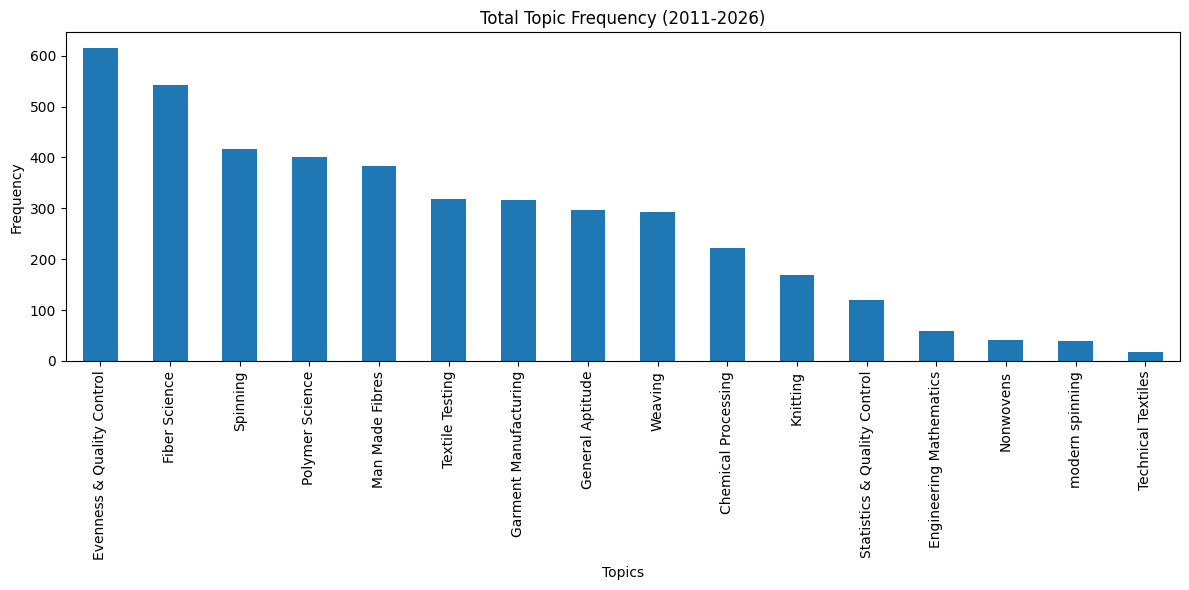

In [34]:
# ==========================================
# BAR CHART
# ==========================================

plt.figure(figsize=(12,6))

topic_summary.plot(kind="bar")

plt.title("Total Topic Frequency (2011-2026)")

plt.xlabel("Topics")

plt.ylabel("Frequency")

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

In [35]:
# ==========================================
# YEAR-WISE TREND ANALYSIS
# ==========================================

pivot_df = df.pivot_table(

    index="Year",

    columns="Topic",

    values="Frequency",

    aggfunc="sum"

)
# Fill missing values
pivot_df = pivot_df.fillna(0)

print("\n===================================")
print("YEAR-WISE TREND TABLE")
print("===================================")

print(pivot_df)



YEAR-WISE TREND TABLE
Topic  Chemical Processing  Engineering Mathematics  \
Year                                                  
2011                     1                        2   
2012                     8                        4   
2013                    10                        1   
2014                    14                        4   
2015                    13                        9   
2016                    30                        4   
2017                    11                        5   
2018                    16                        2   
2019                    15                        3   
2020                     6                        3   
2021                    10                        2   
2022                    15                        5   
2023                    24                        5   
2024                    13                        3   
2025                    15                        4   
2026                    21                

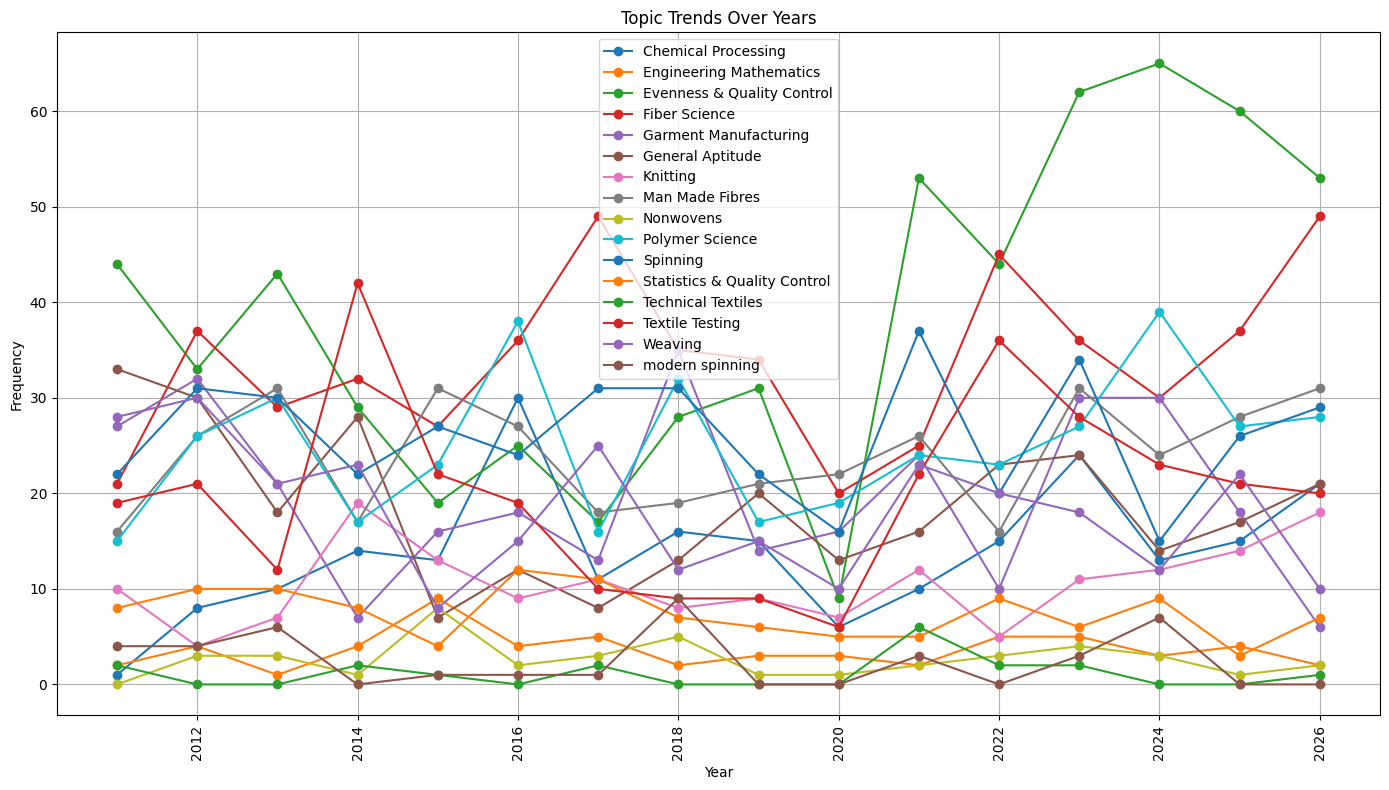

In [36]:
# ==========================================
# LINE PLOT FOR TRENDS
# ==========================================

plt.figure(figsize=(14,8))

for column in pivot_df.columns:

    plt.plot(

        pivot_df.index,

        pivot_df[column],

        marker='o',

        label=column

    )

plt.title("Topic Trends Over Years")

plt.xlabel("Year")

plt.ylabel("Frequency")

plt.legend()

plt.grid(True)

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()



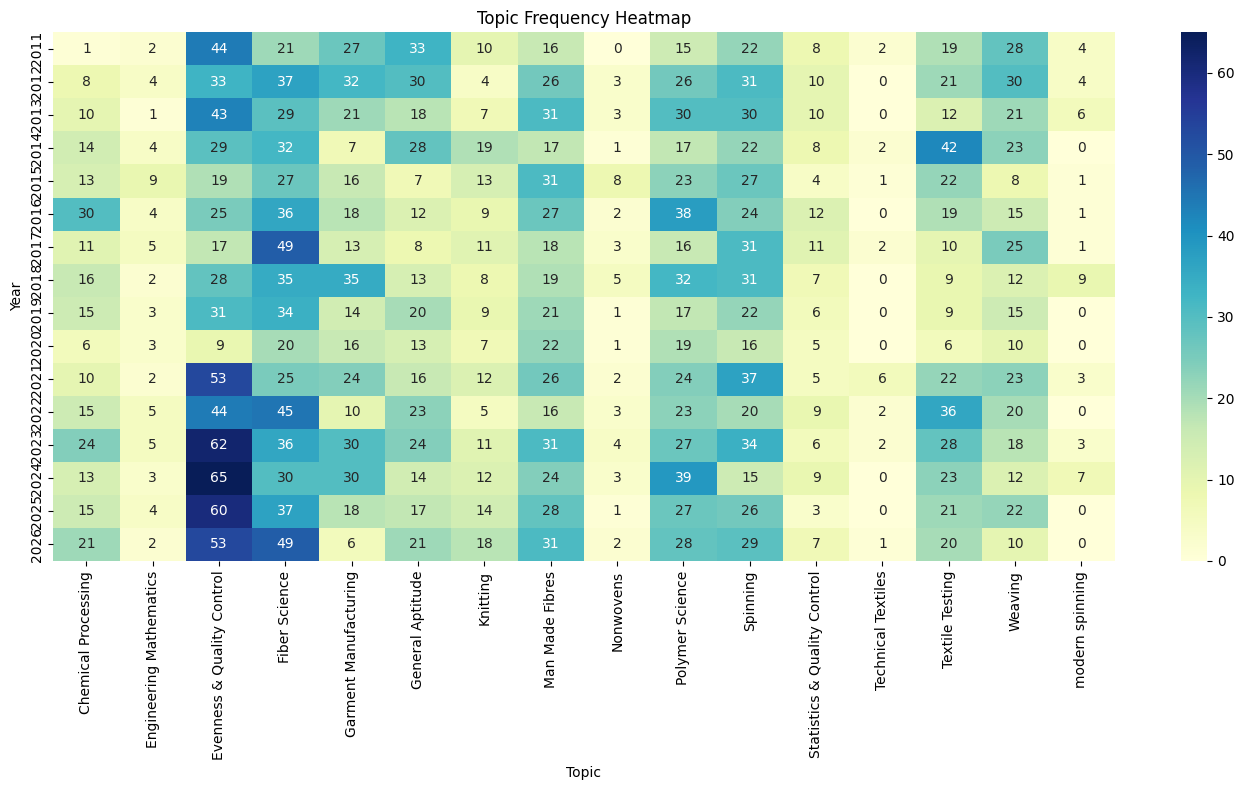

In [37]:
# ==========================================
# HEATMAP
# ==========================================

plt.figure(figsize=(14,8))

sns.heatmap(

    pivot_df,

    annot=True,

    cmap="YlGnBu"

)

plt.title("Topic Frequency Heatmap")

plt.tight_layout()

plt.show()


In [38]:
# ==========================================
# TREND SCORE CALCULATION (with scipy linregress)
# ==========================================

from scipy import stats
import numpy as np

trend_scores = {}

for topic in pivot_df.columns:
    topic_data = pivot_df[topic].values
    years_numeric = np.arange(len(pivot_df.index))
    
    # Linear regression: does this topic grow or decline?
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        years_numeric, topic_data
    )
    
    # Use slope as trend score (positive = growing, negative = declining)
    trend_scores[topic] = slope

# ==========================================
# DISPLAY TREND SCORES
# ==========================================

trend_df = pd.DataFrame({
    "Topic": trend_scores.keys(),
    "Trend": trend_scores.values()
})

trend_df = trend_df.sort_values(
    by="Trend",
    ascending=False
)

print("\n===================================")
print("TREND SCORES (from linear regression)")
print("===================================")
print(f"Positive slope = growing topic")
print(f"Negative slope = declining topic")
print("\n")
print(trend_df)

# ==========================================
# SAVE TREND ANALYSIS
# ==========================================

output_path = r"D:\TF_Gate_Topic_predictor\data\trend_analysis.csv"

trend_df.to_csv(output_path, index=False)

print("\nTrend analysis saved successfully!")
print(output_path)


TREND SCORES (from linear regression)
Positive slope = growing topic
Negative slope = declining topic


                           Topic     Trend
2     Evenness & Quality Control  1.939706
3                  Fiber Science  0.661765
0            Chemical Processing  0.605882
9                Polymer Science  0.472059
7                Man Made Fibres  0.300000
6                       Knitting  0.266176
13               Textile Testing  0.163235
12            Technical Textiles  0.023529
1        Engineering Mathematics -0.017647
8                      Nonwovens -0.020588
10                      Spinning -0.080882
15               modern spinning -0.122059
11  Statistics & Quality Control -0.226471
4          Garment Manufacturing -0.316176
5               General Aptitude -0.404412
14                       Weaving -0.641176

Trend analysis saved successfully!
D:\TF_Gate_Topic_predictor\data\trend_analysis.csv


In [39]:
!pip install scikit-learn



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
# GATE TF PREDICTION ENGINE
# WITH NORMALIZATION
# ==========================================

import pandas as pd

from sklearn.preprocessing import MinMaxScaler
from scipy import stats

# ==========================================
# LOAD CSV FILES
# ==========================================
from pathlib import Path

# Notebook-safe base directory: prefer current folder, fallback to parent
BASE_DIR = Path().resolve()

if (BASE_DIR / "data").exists():
    DATA_DIR = BASE_DIR / "data"
else:
    DATA_DIR = BASE_DIR.parent / "data"


frequency_path = DATA_DIR / "topic_frequency.csv"

trend_path = DATA_DIR / "trend_analysis.csv"

freq_df = pd.read_csv(frequency_path)

trend_df = pd.read_csv(trend_path)

# ==========================================
# TOTAL TOPIC FREQUENCY
# ==========================================

total_frequency = freq_df.groupby("Topic")[
    "Frequency"
].sum()

# ==========================================
# RECENT YEARS ANALYSIS
# ==========================================

recent_years = ["2023", "2022", "2021","2024", "2025", "2026"]

recent_df = freq_df[
    freq_df["Year"].astype(str).isin(recent_years)
]

recent_frequency = recent_df.groupby("Topic")[
    "Frequency"
].sum()

# ==========================================
# STORE PREDICTION RESULTS
# ==========================================

prediction_results = []

# ==========================================
# CALCULATE RAW SCORES
# ==========================================

for topic in total_frequency.index:

    # --------------------------------------
    # TOTAL FREQUENCY
    # --------------------------------------

    freq_score = total_frequency[topic]

    # --------------------------------------
    # TREND SCORE
    # --------------------------------------

    trend_row = trend_df[
        trend_df["Topic"] == topic
    ]

    
    if not trend_row.empty:

        
        trend_score = trend_row[
            "Trend"
        ].values[0]

    else:

        trend_score = 0

    # --------------------------------------
    # RECENT YEARS SCORE
    # --------------------------------------

    if topic in recent_frequency.index:

        recent_score = recent_frequency[topic]

    else:

        recent_score = 0

    # --------------------------------------
    # STORE RAW VALUES
    # --------------------------------------

    prediction_results.append({

        "Topic": topic,

        "Total Frequency": freq_score,

        "Trend Score": trend_score,

        "Recent Weight": recent_score

    })

# ==========================================
# CREATE DATAFRAME
# ==========================================

prediction_df = pd.DataFrame(
    prediction_results
)

# ==========================================
# NORMALIZATION
# ==========================================

scaler = MinMaxScaler()

columns_to_normalize = [

    "Total Frequency",

    "Trend Score",

    "Recent Weight"

]

prediction_df[columns_to_normalize] = scaler.fit_transform(

    prediction_df[columns_to_normalize]

)

# ==========================================
# FINAL PREDICTION SCORE
# ==========================================

prediction_df["Prediction Score"] = (

    prediction_df["Total Frequency"] * 0.6 +

    prediction_df["Trend Score"] * 0.1 +

    prediction_df["Recent Weight"] * 0.3

)

# ==========================================
# ROUND VALUES
# ==========================================

prediction_df = prediction_df.round(3)

# ==========================================
# SORT BY PREDICTION SCORE
# ==========================================

prediction_df = prediction_df.sort_values(

    by="Prediction Score",

    ascending=False

)

# ==========================================
# DISPLAY RESULTS
# ==========================================

print("\n===================================")
print("PREDICTED HIGH-WEIGHTAGE TOPICS")
print("===================================")

print(prediction_df)

# ==========================================
# TOP 5 PREDICTED TOPICS
# ==========================================

print("\n===================================")
print("TOP 5 PREDICTED TOPICS")
print("===================================")

top_5 = prediction_df.head(5)

for i, row in enumerate(top_5.values, start=1):

    print(f"{i}. {row[0]}")

# ==========================================
# SAVE CSV
# ==========================================

output_path = r"D:\TF_Gate_Topic_predictor\data\predicted_topics.csv"

prediction_df.to_csv(output_path, index=False)

# ==========================================
# FINISHED
# ==========================================

print("\n===================================")
print("PREDICTION FILE CREATED!")
print("===================================")

print(f"\nSaved at:\n{output_path}")



PREDICTED HIGH-WEIGHTAGE TOPICS
                           Topic  Total Frequency  Trend Score  Recent Weight  \
2     Evenness & Quality Control            1.000        1.000          1.000   
3                  Fiber Science            0.878        0.505          0.647   
9                Polymer Science            0.642        0.431          0.482   
10                      Spinning            0.668        0.217          0.460   
7                Man Made Fibres            0.613        0.365          0.445   
13               Textile Testing            0.504        0.312          0.426   
4          Garment Manufacturing            0.501        0.126          0.328   
5               General Aptitude            0.467        0.092          0.319   
14                       Weaving            0.459        0.000          0.288   
0            Chemical Processing            0.342        0.483          0.267   
6                       Knitting            0.253        0.352          0.18

In [1]:
import os

print(os.getcwd())

d:\TF_Gate_Topic_predictor\gate_topic_predictor
